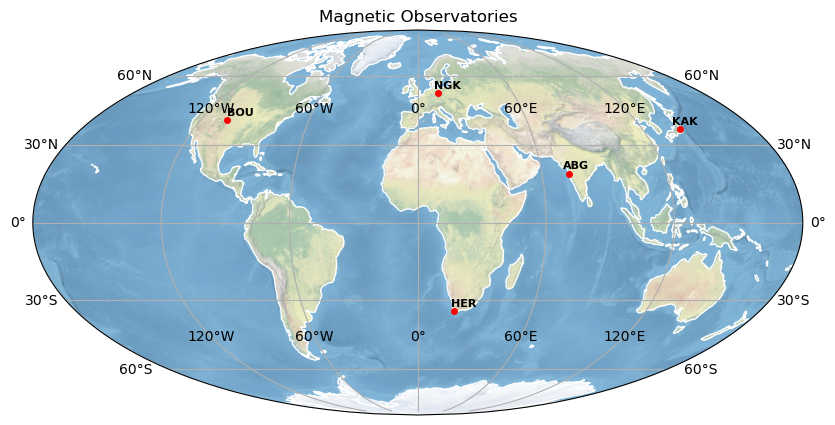

In [31]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# figure and the axes with Mollweide projection
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.Mollweide())

# add coastlines, stock image (basically colors of land and water), and gridlines
ax.coastlines(resolution='110m', color='white', linewidth=1) # 10m high 50m medium 110m low
ax.stock_img()
ax.gridlines(draw_labels=True)

# add the locations of the magnetic observatories
observatories = {
    'ABG': (72.8722, 18.6411),
    'KAK': (140.1833, 36.2333),
    'NGK': (12.7167, 52.0667),
    'BOU': (-105.1779, 40.1173),
    'HER': (19.2340, -34.4170),
}

# plot the observatories on the map
for name, (lon, lat) in observatories.items():
    ax.plot(lon, lat, marker='o', color='red', markersize=4, transform=ccrs.Geodetic())
    ax.text(lon - 2, lat + 2, name, fontsize=8, fontweight='bold', transform=ccrs.Geodetic())
plt.title("Magnetic Observatories")
plt.show()

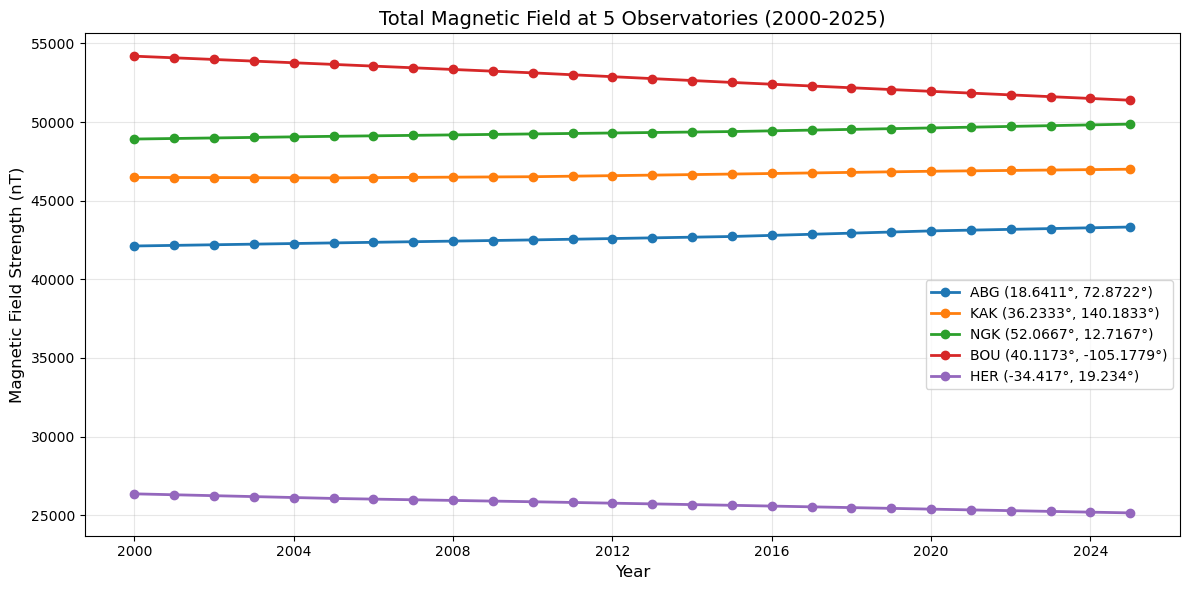

In [ ]:
import ppigrf
from datetime import datetime
import numpy as np

# Observatories with their coordinates (latitude, longitude)
observatories = {
    'ABG': (18.6411, 72.8722),
    'KAK': (36.2333, 140.1833),
    'NGK': (52.0667, 12.7167),
    'BOU': (40.1173, -105.1779),
    'HER': (-34.4170, 19.2340),
}

altitude = 0  # sea level
# date = datetime(2024, 1, 1)  # example date (January 1, 2024)
# Create a datetime range of years (2000-2025)
dat = np.arange('2000', '2026', dtype='datetime64[Y]')

# Create figure
plt.figure(figsize=(12, 6))

# Plot data for each observatory
for name, (lat, lon) in observatories.items():
    # Field components
    Be, Bn, Bz = ppigrf.igrf(lon, lat, altitude, dat)
    B_tot = np.sqrt(Be**2 + Bn**2 + Bz**2)
    plt.plot(dat, B_tot, marker='o', label=f'{name} ({lat}°, {lon}°)', linewidth=2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Magnetic Field Strength (nT)', fontsize=12)
plt.title('Total Magnetic Field at 5 Observatories (2000-2025)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10,loc='center right', bbox_to_anchor=(1, 0.4))
plt.tight_layout()
plt.show()


In [46]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from datetime import datetime
import ppigrf

In [47]:
# Values for lat, lon, altitude, and date
lat = np.arange(-90, 90, 1)  # Latitude from -90 to 90 degrees
lon = np.arange(0, 360, 1)   # Longitude from 0 to 360 degrees
altitude = 0                 # Sea level
date = datetime(1999,6,6)    # Example date (June 6, 2020)

print(lat.shape , lon.shape)

# Create 2D grid of latitudes and longitudes
lon_grid, lat_grid = np.meshgrid(lon, lat)

print(lon_grid.shape, lat_grid.shape)

(180,) (360,)
(180, 360) (180, 360)


In [48]:
# Calculate magnetic field components and total field strength
Be, Bn, Bz = ppigrf.igrf(lon_grid, lat_grid, altitude, date)
B_tot = np.sqrt(Be**2 + Bn**2 + Bz**2)

print(Be.shape, Bn.shape, Bz.shape, B_tot.shape)

(1, 180, 360) (1, 180, 360) (1, 180, 360) (1, 180, 360)


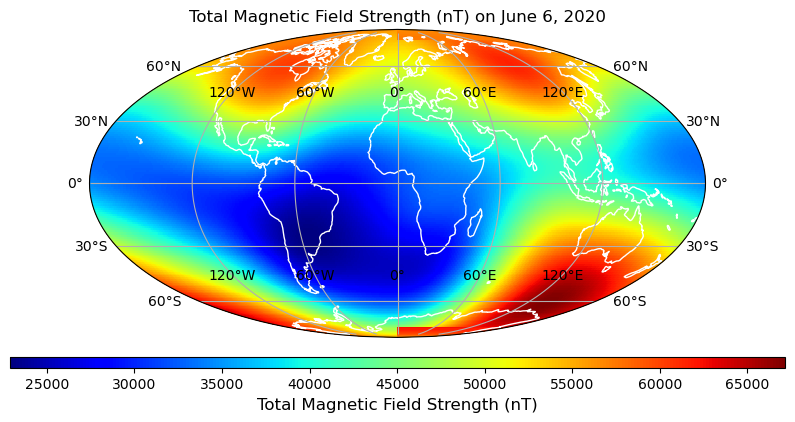

In [49]:
# figure and the axes with Mollweide projection
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.Mollweide())

# add coastlines, stock image (basically colors of land and water), and gridlines
ax.coastlines(resolution='110m', color='white', linewidth=1) # 10m high 50m medium 110m low
# ax.stock_img()
ax.gridlines(draw_labels=True)

T = ax.pcolormesh(lon_grid, lat_grid, B_tot.squeeze(), cmap = 'jet',transform=ccrs.PlateCarree())

cbar = plt.colorbar(T, orientation = 'horizontal', pad = 0.05, aspect = 70)
cbar.set_label('Total Magnetic Field Strength (nT)', fontsize=12)

plt.title("Total Magnetic Field Strength (nT) on June 6, 2020")
plt.show()